<a href="https://colab.research.google.com/github/saim9211/Machine-Learning-Stuff/blob/main/Outlier_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("placement.csv")
df.sample(2)

,cgpa,placement_exam_marks,placed
476,6.83,34.0,0
968,6.84,26.0,0


In [ ]:
df.describe()

,cgpa,placement_exam_marks,placed
count,1000.000000,1000.000000,1000.000000
mean,6.961240,32.225000,0.489000
std,0.615898,19.130822,0.500129
min,4.890000,0.000000,0.000000
25%,6.550000,17.000000,0.000000
50%,6.960000,28.000000,0.000000
75%,7.370000,44.000000,1.000000
max,9.120000,100.000000,1.000000


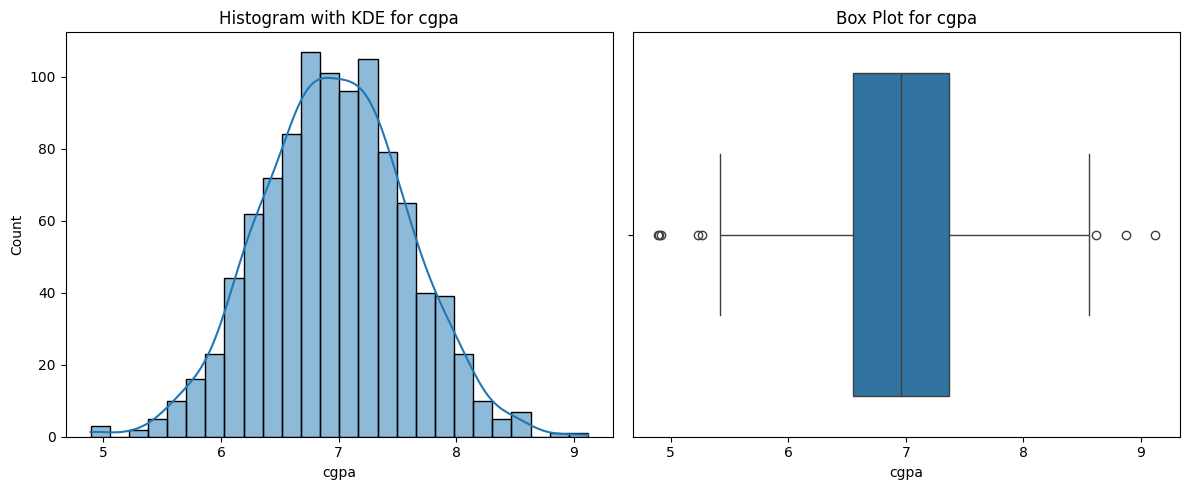

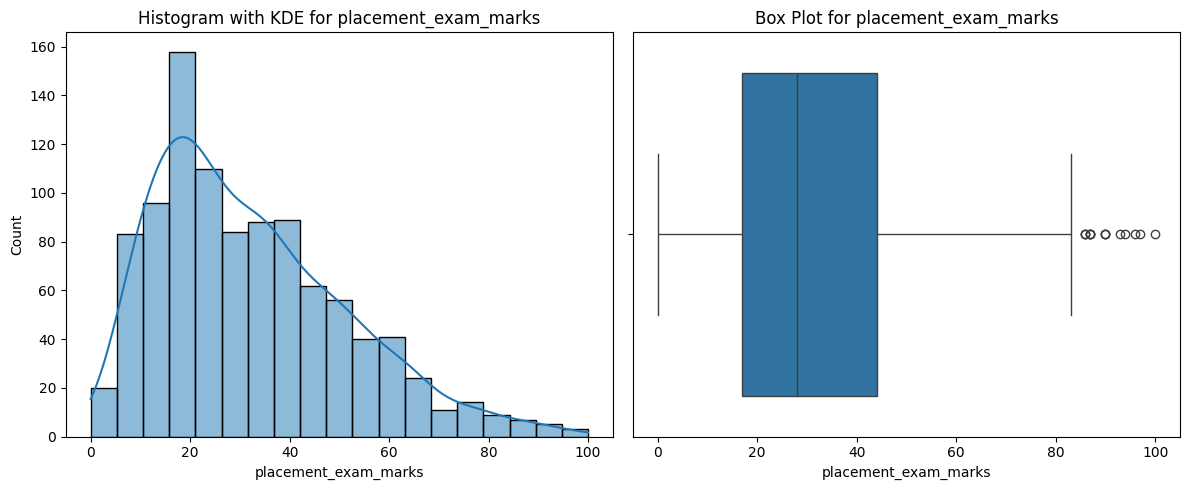

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ['cgpa', 'placement_exam_marks']


# Plotting Histograms with KDE and Box plots for numerical columns
for col in numerical_cols:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Histogram with KDE for {col}')

    plt.subplot(1, 2, 2)
    sns.boxplot(data=df, x=col)
    plt.title(f'Box Plot for {col}')

    plt.tight_layout()
    plt.show()



In [ ]:
 pip install feature-engine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 5.5 MB/s eta 0:00:00


In [ ]:

from feature_engine.outliers import Winsorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(df.drop('placed',axis=1),df['placed'],test_size=0.2,random_state=42)

In [ ]:
print("First 5 rows of training data after outlier removal:\n", x_train_processed_df.head())
print("\nFirst 5 rows of testing data after outlier removal:\n", x_test_processed_df.head())

First 5 rows of training data after outlier removal:
    cgpa  placement_exam_marks
0  6.51             15.000000
1  6.49             61.226873
2  6.75             11.000000
3  6.47             25.000000
4  7.09             33.000000

First 5 rows of testing data after outlier removal:
        cgpa  placement_exam_marks
0  6.039602             37.000000
1  6.520000             12.000000
2  6.210000             61.226873
3  6.039602             26.000000
4  6.040000             61.226873



--- Visualizing x_train_processed after Outlier Removal ---


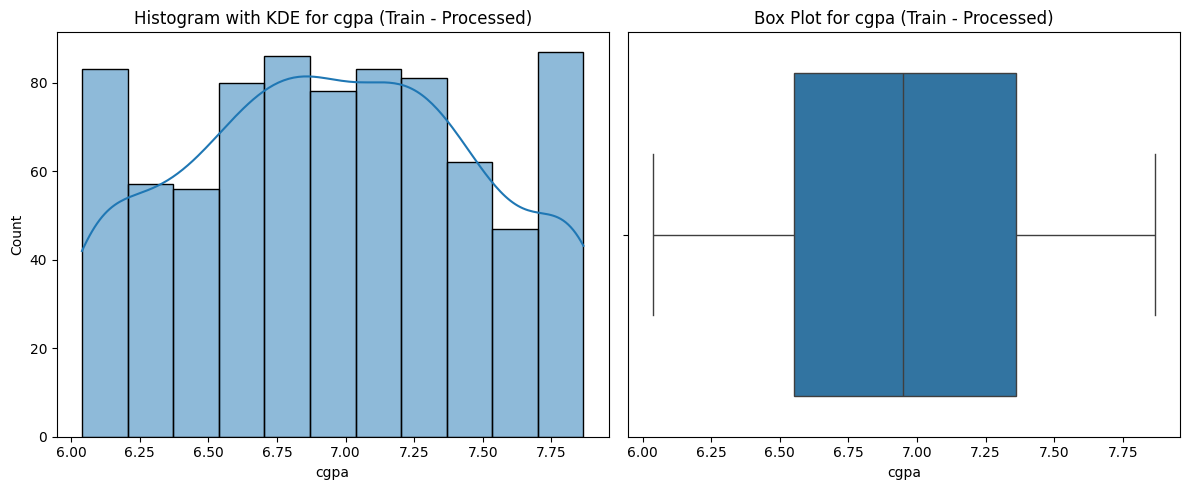

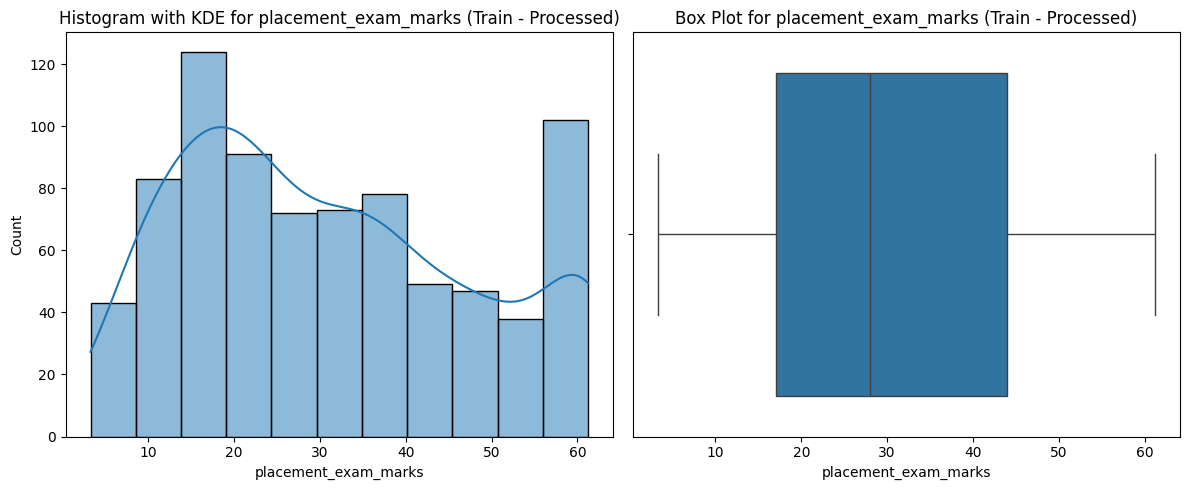


--- Visualizing x_test_processed after Outlier Removal ---


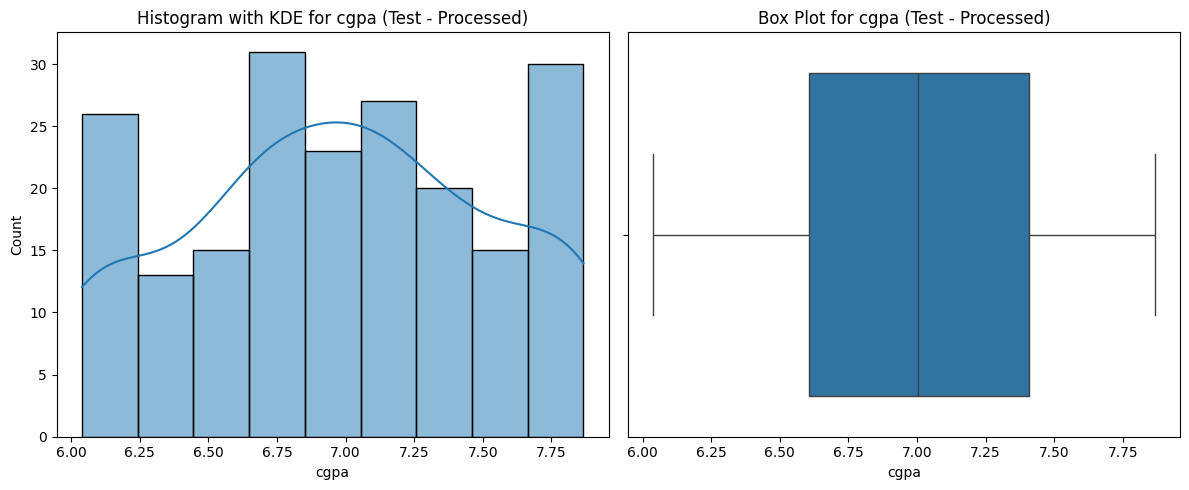

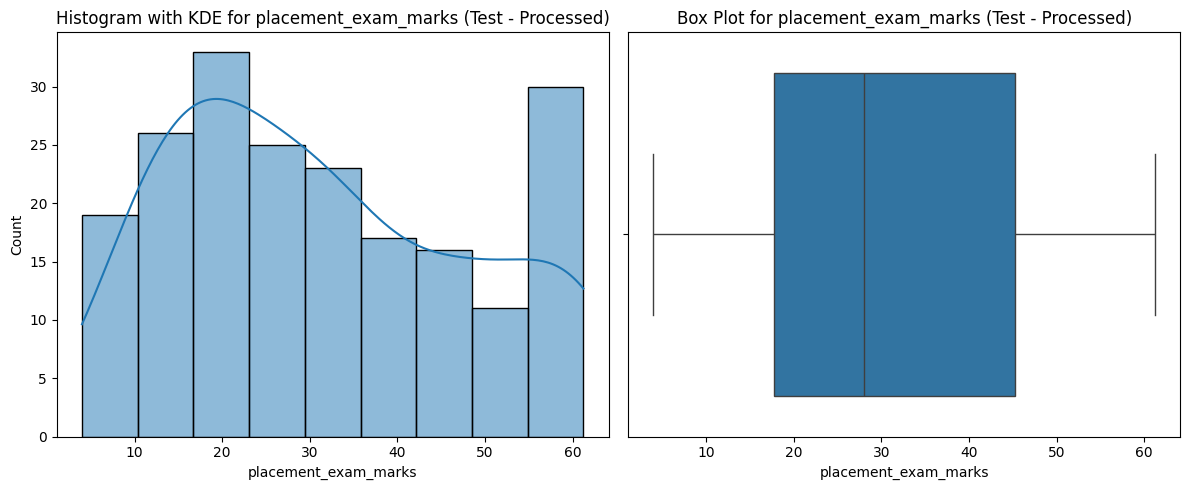

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert processed numpy arrays back to DataFrames for easier plotting
x_train_processed_df = pd.DataFrame(x_train_processed, columns=numerical_cols)
x_test_processed_df = pd.DataFrame(x_test_processed, columns=numerical_cols)

print("\n--- Visualizing x_train_processed after Outlier Removal ---")
for col in numerical_cols:
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    sns.histplot(data=x_train_processed_df, x=col, kde=True)
    plt.title(f'Histogram with KDE for {col} (Train - Processed)')

    plt.subplot(1, 2, 2)
    sns.boxplot(data=x_train_processed_df, x=col)
    plt.title(f'Box Plot for {col} (Train - Processed)')

    plt.tight_layout()
    plt.show()

print("\n--- Visualizing x_test_processed after Outlier Removal ---")
for col in numerical_cols:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.histplot(data=x_test_processed_df, x=col, kde=True)
    plt.title(f'Histogram with KDE for {col} (Test - Processed)')

    plt.subplot(1, 2, 2)
    sns.boxplot(data=x_test_processed_df, x=col)
    plt.title(f'Box Plot for {col} (Test - Processed)')

    plt.tight_layout()
    plt.show()

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from feature_engine.outliers import Winsorizer

# Define the numerical columns for outlier handling
numerical_cols = ['cgpa', 'placement_exam_marks']

# Create the Winsorizer transformer
# Using 'gaussian' capping for both tails based on typical distribution assumptions
winsorizer = Winsorizer(capping_method='gaussian', tail='both', fold=1.5, variables=numerical_cols)

# Create a ColumnTransformer to apply the Winsorizer to the specified numerical columns
preprocessor = ColumnTransformer(
    transformers=[
        ('outlier_capper', winsorizer, numerical_cols)
    ],
    remainder='passthrough' # Keep other columns as they are
)

# Create the full pipeline
pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

# Now you can fit and transform your data using this pipeline
pipeline.fit(x_train)
x_train_processed = pipeline.transform(x_train)
x_test_processed = pipeline.transform(x_test)

print("Shape of x_train after Winsorization:", x_train_processed.shape)
print("Shape of x_test after Winsorization:", x_test_processed.shape)
print("First 5 rows of processed x_train (cgpa and placement_exam_marks):\n", x_train_processed[:5])

Shape of x_train after Winsorization: (800, 2)
Shape of x_test after Winsorization: (200, 2)
First 5 rows of processed x_train (cgpa and placement_exam_marks):
 [[ 6.51       15.        ]
 [ 6.49       61.22687281]
 [ 6.75       11.        ]
 [ 6.47       25.        ]
 [ 7.09       33.        ]]


In [ ]:
x_train_processed_df = pd.DataFrame(x_train_processed, columns=numerical_cols)
x_test_processed_df = pd.DataFrame(x_test_processed, columns=numerical_cols)
x_train_processed_df.describe()

,cgpa,placement_exam_marks
count,800.000000,800.000000
mean,6.954867,31.140780
std,0.536912,16.868084
min,6.039602,3.268127
25%,6.550000,17.000000
50%,6.950000,28.000000
75%,7.360000,44.000000
max,7.867073,61.226873


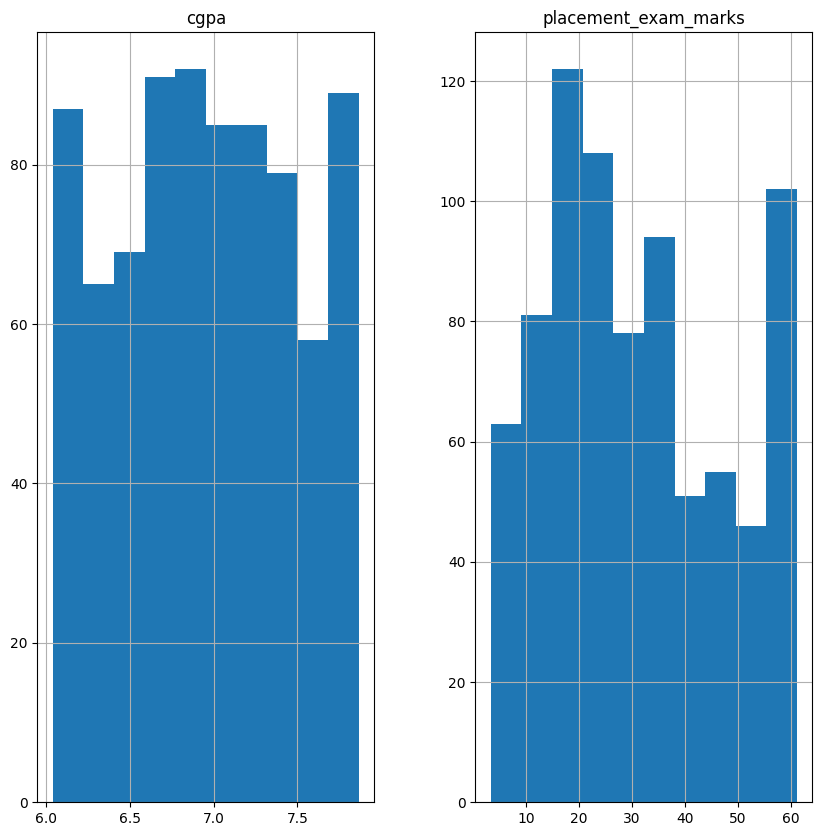

In [ ]:
x_train_processed_df.hist(figsize=(10, 10))
plt.show()

In [ ]:
x_train_processed_df.boxplot(figsize=(10, 10))
plt.show()

AttributeError: 'Series' object has no attribute 'boxplot'

In [ ]:
df.describe()

,cgpa,placement_exam_marks,placed
count,1000.000000,1000.000000,1000.000000
mean,6.961240,32.225000,0.489000
std,0.615898,19.130822,0.500129
min,4.890000,0.000000,0.000000
25%,6.550000,17.000000,0.000000
50%,6.960000,28.000000,0.000000
75%,7.370000,44.000000,1.000000
max,9.120000,100.000000,1.000000
